In [30]:
import numpy as np
import matplotlib.pyplot as plt


Density       Least-square deviation
1.00e+09    1.597e-01
3.16e+09    9.366e-02
1.00e+10    3.262e-02
1.00e+12    0.000e+00
1.00e+15    0.000e+00
1.00e+20    0.000e+00


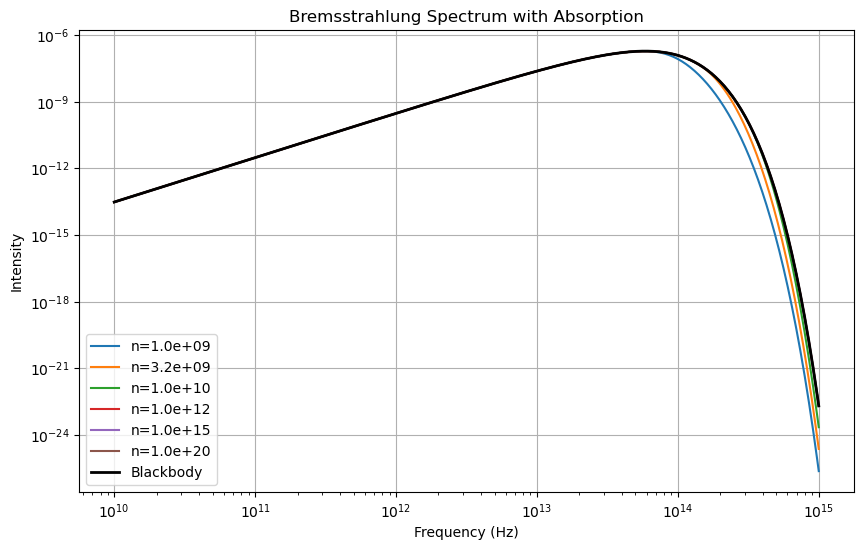

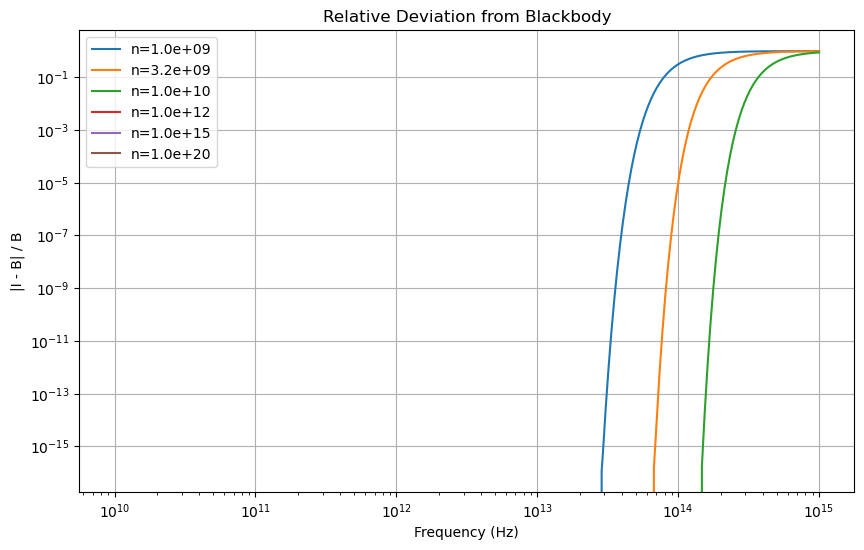

In [33]:
# ================= CONSTANTS (cgs) =================
h = 6.626e-27
k = 1.38e-16
c = 3e10

# ================= PARAMETERS =================
T = 1000.0
L = 1e17
g_ff = 1.0

nu = np.logspace(10, 15, 500)
exponents = np.array([9, 9.5, 10, 12, 15, 20])
densities = 10**exponents

# ================= FUNCTIONS =================

def j_nu(ne, nu):
    return 6.8e-38 * ne**2 * T**(-0.5) * np.exp(-h*nu/(k*T)) * g_ff / 4 / np.pi

def B_nu(nu):
    return (2*h*nu**3 / c**2) / (np.expm1(h*nu/(k*T)))

# ================= COMPUTATION =================

B = B_nu(nu)

plt.figure(figsize=(10,6))

print("Density       Least-square deviation")

for ne in densities:

    j = j_nu(ne, nu)

    # enforce Kirchhoff
    alpha = j / B
    tau = alpha * L

    I = B * (1 - np.exp(-tau))

    # least-square deviation
    chi2 = np.mean(((I - B) / B)**2)

    print(f"{ne:.2e}    {chi2:.3e}")

    plt.loglog(nu, I, label=f"n={ne:.1e}")

# blackbody
plt.loglog(nu, B, 'k-', linewidth=2, label='Blackbody')

plt.xlabel("Frequency (Hz)")
plt.ylabel("Intensity")
plt.title("Bremsstrahlung Spectrum with Absorption")
plt.legend()
plt.grid()
plt.show()

# ================= RELATIVE DIFFERENCE =================

plt.figure(figsize=(10,6))

for ne in densities:

    j = j_nu(ne, nu)
    alpha = j /np.maximum(B, 1e-40)
    tau = alpha * L

    I = B * (1 - np.exp(-tau))

    diff = np.abs(I - B) / B
    plt.loglog(nu, diff, label=f"n={ne:.1e}")

plt.xlabel("Frequency (Hz)")
plt.ylabel("|I - B| / B")
plt.title("Relative Deviation from Blackbody")
plt.legend()
plt.grid()
plt.show()